# Language-Aware Layer Pruning in Small Multilingual LLMs — v3 (corrected + optimised + Belebele)

**Research question:** Does the calibration language (English / Hindi / Marathi / mixed) change which
Transformer layers look redundant, and does English-calibrated pruning transfer to Indic languages?

## What changed vs. v1 (and why it matters for the paper)

| # | v1 problem | Effect on results | v2 fix |
|---|---|---|---|
| 1 | Calibration and evaluation chunks were built from the **same first rows** of the same stream → identical data | Calibration/evaluation leakage; violates the guide's own rule | Article-level disjoint split, asserted |
| 2 | Last layer's "output" was `hidden_states[-1]`, which in HF already has the **final RMSNorm** applied | Last-layer influence is wrong (compares un-normed input with normed output) | Forward hooks capture true block outputs |
| 3 | Pruning loop runs `del model` on every iteration → `NameError` on iteration 2; later cells also use the deleted `model` | Notebook cannot run top-to-bottom | Layers are swapped out and restored on one model (weights untouched; equivalent to a fresh model, verified) |
| 4 | Stability = shuffle the **same 20 chunks** twice; influence is a mean, so order is irrelevant → Jaccard ≡ 1.0 | Stability metric is meaningless | Independent random calibration subsets across seeds (mean ± std) |
| 5 | Random baseline only printed layer ids, never evaluated | No control | Random (10 seeds) and a "deep contiguous block" heuristic are evaluated |
| 6 | First 2000 rows of the stream (not random), 20 chunks, single seed | Tiny, biased sample | Shuffled stream, 200 calibration + 100 eval chunks/lang, ≤2 chunks per article, 5 seeds |
| 7 | Mixed calibration silently used 3× the tokens of single-language calibration | Token-budget confound | Seeded experiments use equal total token budgets |
| 8 | No uncertainty on PPL differences | Claims not testable | Paired bootstrap CIs over evaluation chunks |
| 9 | Chunks had no BOS token | Gemma-2 baseline PPL explodes (EN ≈182, MR ≈2557); Llama slightly off | BOS prepended for models that define one; BOS position excluded from influence |
| 10 | `json.dumps` on numpy int64 (cell 24) | v1 crashes before pruning starts | Layer ids cast to `int` |

Extras added from the research guide: relative-L2 influence metric, calibration-budget sweep, cross-language
Jaccard of pruning sets, tokenizer statistics on the same articles, multi-model support.

Set the model with the environment variable `MODEL_KEY` (`qwen`, `llama`, `gemma`) or edit the config cell.

In [1]:
import os, gc, math, json, random, hashlib, warnings, itertools, time
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from datasets import load_dataset
from scipy.stats import spearmanr, kendalltau
from transformers import AutoTokenizer, AutoModelForCausalLM
import transformers

warnings.filterwarnings("ignore")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_KEY = os.environ.get("MODEL_KEY", "qwen")
MODELS = {
    "qwen": "Qwen/Qwen2.5-1.5B-Instruct",
    # Official repos are gated. Ungated re-uploads are used for this run; for the paper,
    # re-run with the official IDs (meta-llama/Llama-3.2-1B, google/gemma-2-2b) after HF login.
    "llama": os.environ.get("LLAMA_ID", "unsloth/Llama-3.2-1B"),
    "gemma": os.environ.get("GEMMA_ID", "unsloth/gemma-2-2b"),
}
LANGS = ["en", "hi", "mr"]
LANG_CODES = {"en": "20231101.en", "hi": "20231101.hi", "mr": "20231101.mr"}
CONDITIONS = ["en", "hi", "mr", "mixed"]

SEQ_LEN = 256
CALIB_POOL_CHUNKS = 200        # per language, used for the reference ranking
EVAL_CHUNKS = 100              # per language, held-out articles
MAX_CHUNKS_PER_ARTICLE = 2     # diversity: no single article dominates
N_ARTICLES_TO_SCAN = 1500
SHUFFLE_BUFFER = 5000
MIN_WORDS = 30

PRUNE_LEVELS = [2, 4, 6]
N_SEEDS = 5                    # calibration-subset seeds
SEEDED_BUDGET = 60             # total chunks per seeded calibration set (mixed = 20/lang)
BUDGETS = [3, 6, 15, 30, 60, 150]   # total chunks; mixed splits equally across languages
BUDGET_K = 4
N_RANDOM_SEEDS = 10
N_BOOT = 2000
INF_BATCH = 8 if MODEL_KEY == "gemma" else 16
EVAL_BATCH = 4 if MODEL_KEY == "gemma" else 8
RUN_BELEBELE = os.environ.get("RUN_BELEBELE", "1") == "1"
N_BELEBELE = 300                    # same parallel questions in EN/HI/MR
BELEBELE_RANDOM_SEEDS = 2           # random-pruning controls evaluated on Belebele
BELEBELE_CODES = {"en": "eng_Latn", "hi": "hin_Deva", "mr": "mar_Deva"}

ROOT = Path.cwd()
DATA_CACHE = ROOT.parent / "data" / "calibration-cache"; DATA_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = ROOT / "results" / MODEL_KEY; OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" and torch.cuda.is_bf16_supported() else (
    torch.float16 if DEVICE == "cuda" else torch.float32)

# Fixed colour per condition across every figure (identity, never rank)
COLORS = {"en": "#2a78d6", "hi": "#eb6834", "mr": "#1baf7a", "mixed": "#eda100",
          "random": "#8a8984", "deep_block": "#4a3aa7"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "lines.linewidth": 2,
                     "figure.dpi": 110, "savefig.dpi": 200})

print("torch", torch.__version__, "| transformers", transformers.__version__)
print("Device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE == "cuda" else "", "| dtype:", DTYPE)
print("Model:", MODELS[MODEL_KEY], "| output:", OUTPUT_DIR)

torch 2.5.1+cu121 | transformers 4.56.2
Device: cuda NVIDIA GeForce RTX 4060 Laptop GPU | dtype: torch.bfloat16
Model: unsloth/gemma-2-2b | output: results\gemma


## 1. Load model (once) and locate Transformer blocks

In [2]:
def load_model(model_key):
    name = MODELS[model_key]
    tok = AutoTokenizer.from_pretrained(name)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    kwargs = dict(torch_dtype=DTYPE)
    if "gemma" in name.lower():
        kwargs["attn_implementation"] = "eager"   # recommended for Gemma-2 soft-capping
    mdl = AutoModelForCausalLM.from_pretrained(name, **kwargs).to(DEVICE)
    mdl.eval()
    return tok, mdl

BLOCK_PATHS = ["model.layers", "model.decoder.layers", "transformer.h", "decoder.layers"]

def _resolve(obj, path):
    for p in path.split("."):
        obj = getattr(obj, p)
    return obj

def get_transformer_blocks(model):
    for path in BLOCK_PATHS:
        try:
            blocks = _resolve(model, path)
            if isinstance(blocks, nn.ModuleList) and len(blocks) > 0:
                return blocks, path
        except AttributeError:
            pass
    raise RuntimeError("Could not find Transformer blocks.")

def set_transformer_blocks(model, new_blocks, path):
    parent_path, attr = path.rsplit(".", 1)
    setattr(_resolve(model, parent_path), attr, nn.ModuleList(new_blocks))

tokenizer, model = load_model(MODEL_KEY)
BLOCKS, BLOCK_PATH = get_transformer_blocks(model)
ORIGINAL_BLOCKS = list(BLOCKS)
N_LAYERS = len(ORIGINAL_BLOCKS)
cfg = model.config
model_info = {
    "model_key": MODEL_KEY, "model_id": MODELS[MODEL_KEY],
    "parameters": sum(p.numel() for p in model.parameters()),
    "layers": N_LAYERS, "hidden_size": cfg.hidden_size,
    "attention_heads": cfg.num_attention_heads,
    "kv_heads": getattr(cfg, "num_key_value_heads", None),
    "vocab_size": len(tokenizer), "block_path": BLOCK_PATH,
}
print(json.dumps(model_info, indent=2))

`torch_dtype` is deprecated! Use `dtype` instead!


{
  "model_key": "gemma",
  "model_id": "unsloth/gemma-2-2b",
  "parameters": 2614341888,
  "layers": 26,
  "hidden_size": 2304,
  "attention_heads": 8,
  "kv_heads": 4,
  "vocab_size": 256000,
  "block_path": "model.layers"
}


## 2. Data: shuffled Wikipedia, article-level disjoint calibration / evaluation

Articles are sampled from a shuffled stream and cached to disk, so **every model sees exactly the same
articles** (token chunks differ only because tokenizers differ). Evaluation articles never appear in calibration.

In [3]:
def load_articles(lang):
    cache = DATA_CACHE / f"{lang}_articles_seed{SEED}_n{N_ARTICLES_TO_SCAN}.json"
    if cache.exists():
        return json.loads(cache.read_text(encoding="utf-8"))
    ds = load_dataset("wikimedia/wikipedia", LANG_CODES[lang], split="train", streaming=True)
    ds = ds.shuffle(seed=SEED, buffer_size=SHUFFLE_BUFFER)
    arts = []
    for row in ds:
        text = row.get("text", "")
        if text and len(text.split()) >= MIN_WORDS:
            arts.append({"id": row["id"], "title": row["title"], "text": text})
        if len(arts) >= N_ARTICLES_TO_SCAN:
            break
    cache.write_text(json.dumps(arts, ensure_ascii=False), encoding="utf-8")
    return arts

# Models with a BOS token (Llama, Gemma) need it: Gemma-2 without <bos> gives PPL in the hundreds/thousands.
# Each chunk = [BOS] + (SEQ_LEN-1) text tokens; Qwen has no BOS, so it gets SEQ_LEN text tokens.
BOS = [tokenizer.bos_token_id] if tokenizer.bos_token_id is not None else []
BODY = SEQ_LEN - len(BOS)
SKIP = len(BOS)   # positions excluded from influence (BOS is an attention sink with outlier norms)
print("BOS prepended:", bool(BOS))

def article_chunks(text):
    ids = tokenizer(text, add_special_tokens=False)["input_ids"]
    out = []
    for s in range(0, len(ids) - BODY + 1, BODY):
        out.append(BOS + ids[s:s + BODY])
        if len(out) >= MAX_CHUNKS_PER_ARTICLE:
            break
    return out

articles, calib_pool, eval_chunks, split_stats = {}, {}, {}, []
for lang in LANGS:
    t0 = time.time()
    articles[lang] = load_articles(lang)
    ev, ca, ev_ids, ca_ids = [], [], set(), set()
    for art in articles[lang]:
        ch = article_chunks(art["text"])
        if not ch:
            continue
        if len(ev) < EVAL_CHUNKS:                       # first articles -> evaluation
            ev.extend(ch[: EVAL_CHUNKS - len(ev)]); ev_ids.add(art["id"])
        elif len(ca) < CALIB_POOL_CHUNKS:               # remaining articles -> calibration
            ca.extend(ch[: CALIB_POOL_CHUNKS - len(ca)]); ca_ids.add(art["id"])
        else:
            break
    assert not (ev_ids & ca_ids), "article overlap between calibration and evaluation"
    assert len(ev) == EVAL_CHUNKS and len(ca) == CALIB_POOL_CHUNKS, (lang, len(ev), len(ca))
    hashes = lambda xs: {hashlib.md5(str(x).encode()).hexdigest() for x in xs}
    assert not (hashes(ev) & hashes(ca)), "identical chunk in both splits"
    eval_chunks[lang] = torch.tensor(ev, dtype=torch.long)
    calib_pool[lang] = torch.tensor(ca, dtype=torch.long)
    split_stats.append({"language": lang, "eval_articles": len(ev_ids), "calib_articles": len(ca_ids),
                        "eval_chunks": len(ev), "calib_chunks": len(ca),
                        "eval_tokens": len(ev) * SEQ_LEN, "calib_tokens": len(ca) * SEQ_LEN})
    print(lang, "loaded in %.0fs" % (time.time() - t0))

split_df = pd.DataFrame(split_stats)
split_df.to_csv(OUTPUT_DIR / "data_split.csv", index=False)
display(split_df)

BOS prepended: True


en loaded in 1s


hi loaded in 1s


mr loaded in 1s


,language,eval_articles,calib_articles,eval_chunks,calib_chunks,eval_tokens,calib_tokens
0,en,65,122,100,200,25600,51200
1,hi,58,112,100,200,25600,51200
2,mr,58,113,100,200,25600,51200


## 3. Tokenizer statistics (same articles for every model)

In [4]:
tok_rows = []
for lang in LANGS:
    tpw, cpt = [], []
    for art in articles[lang][:500]:
        words = art["text"].split()
        n_tok = len(tokenizer(art["text"], add_special_tokens=False)["input_ids"])
        tpw.append(n_tok / len(words)); cpt.append(len(art["text"]) / n_tok)
    tok_rows.append({"language": lang, "tokens_per_word_mean": np.mean(tpw),
                     "tokens_per_word_median": np.median(tpw), "chars_per_token_mean": np.mean(cpt),
                     "n_articles": len(tpw)})
token_stats_df = pd.DataFrame(tok_rows)
token_stats_df.to_csv(OUTPUT_DIR / "tokenizer_tokens_per_word.csv", index=False)
display(token_stats_df)

,language,tokens_per_word_mean,tokens_per_word_median,chars_per_token_mean,n_articles
0,en,1.647435,1.596259,4.009958,500
1,hi,2.318610,2.276910,2.447195,500
2,mr,3.430905,3.416793,2.021104,500


## 4. Block influence with true block inputs/outputs

For block $l$ and token $t$: $BI_l = 1 - \cos(h^{in}_{l,t}, h^{out}_{l,t})$ and the alternative
$RL2_l = \lVert h^{out} - h^{in}\rVert / \lVert h^{in}\rVert$, both captured with hooks on the block itself.

We store a **per-chunk** influence matrix (chunks × layers). Any calibration subset's influence is then the
mean of its rows, so stability and budget sweeps need no extra forward passes.
A diagnostic below quantifies the v1 last-layer bug.

In [5]:
def _first_tensor(x):
    return x[0] if isinstance(x, (tuple, list)) else x

@torch.no_grad()
def per_chunk_influence(chunks, check_v1=False):
    blocks, _ = get_transformer_blocks(model)
    store = {}
    def pre(i):
        def fn(module, args, kwargs):
            store[("in", i)] = args[0] if args else kwargs["hidden_states"]
        return fn
    def post(i):
        def fn(module, args, kwargs, output):
            store[("out", i)] = _first_tensor(output)
        return fn
    handles = [b.register_forward_pre_hook(pre(i), with_kwargs=True) for i, b in enumerate(blocks)]
    handles += [b.register_forward_hook(post(i), with_kwargs=True) for i, b in enumerate(blocks)]
    cos_all, l2_all, v1_gap = [], [], []
    try:
        for s in range(0, len(chunks), INF_BATCH):
            ids = chunks[s:s + INF_BATCH].to(DEVICE)
            store.clear()
            out = model.model(input_ids=ids, use_cache=False, output_hidden_states=check_v1)
            cos_b = torch.zeros(ids.shape[0], len(blocks)); l2_b = torch.zeros_like(cos_b)
            for i in range(len(blocks)):
                x = store[("in", i)][:, SKIP:].float(); y = store[("out", i)][:, SKIP:].float()
                cos_b[:, i] = (1 - F.cosine_similarity(x, y, dim=-1)).mean(-1).cpu()
                l2_b[:, i] = ((y - x).norm(dim=-1) / x.norm(dim=-1).clamp_min(1e-6)).mean(-1).cpu()
                if check_v1 and i == len(blocks) - 1:
                    y_v1 = out.hidden_states[i + 1][:, SKIP:].float()   # what v1 used as "block output"
                    v1_gap.append((1 - F.cosine_similarity(x, y_v1, dim=-1)).mean(-1).cpu())
            cos_all.append(cos_b); l2_all.append(l2_b)
    finally:
        for h in handles:
            h.remove()
    res = {"bi": torch.cat(cos_all).numpy(), "rl2": torch.cat(l2_all).numpy()}
    if check_v1:
        res["v1_last"] = torch.cat(v1_gap).numpy()
    return res

t0 = time.time()
chunk_inf = {lang: per_chunk_influence(calib_pool[lang], check_v1=True) for lang in LANGS}
print("influence measured in %.0fs" % (time.time() - t0))

diag = pd.DataFrame([{"language": l,
                      "last_layer_BI_true": chunk_inf[l]["bi"][:, -1].mean(),
                      "last_layer_BI_as_in_v1": chunk_inf[l]["v1_last"].mean()} for l in LANGS])
print("Diagnostic: v1 measured the last layer against the post-final-norm hidden state")
display(diag)
diag.to_csv(OUTPUT_DIR / "diagnostic_v1_last_layer.csv", index=False)

influence measured in 34s
Diagnostic: v1 measured the last layer against the post-final-norm hidden state


,language,last_layer_BI_true,last_layer_BI_as_in_v1
0,en,0.145767,0.317170
1,hi,0.189438,0.242225
2,mr,0.181450,0.231345


In [6]:
def subset_influence(lang_or_mixed, metric, idx_by_lang=None):
    # Mean influence over a calibration subset. Mixed = balanced union of the three languages.
    if lang_or_mixed == "mixed":
        langs = LANGS
    else:
        langs = [lang_or_mixed]
    rows = []
    for l in langs:
        m = chunk_inf[l][metric]
        rows.append(m if idx_by_lang is None else m[idx_by_lang[l]])
    return np.concatenate(rows).mean(0)

influence = {m: pd.DataFrame({c: subset_influence(c, m) for c in CONDITIONS}) for m in ["bi", "rl2"]}
for m, df in influence.items():
    df.index.name = "layer"
    df.to_csv(OUTPUT_DIR / f"block_influence_{m}_by_language.csv")
influence["bi"].to_csv(OUTPUT_DIR / "block_influence_by_language.csv")
display(influence["bi"].style.format("{:.4f}").background_gradient(axis=0, cmap="Blues"))
print("Note: with equal chunks per language, mixed influence == mean of the three language influences:",
      np.allclose(influence["bi"]["mixed"], influence["bi"][LANGS].mean(1)))

,en,hi,mr,mixed
layer,,,,
0,0.3414,0.1980,0.2172,0.2522
1,0.2656,0.2340,0.2155,0.2384
2,0.3521,0.3088,0.2981,0.3197
3,0.2089,0.1993,0.2016,0.2033
4,0.2284,0.2214,0.2207,0.2235
5,0.1606,0.1595,0.1600,0.1600
6,0.1807,0.1649,0.1669,0.1708
7,0.1439,0.1357,0.1321,0.1372
8,0.0960,0.0956,0.0939,0.0952


Note: with equal chunks per language, mixed influence == mean of the three language influences: True


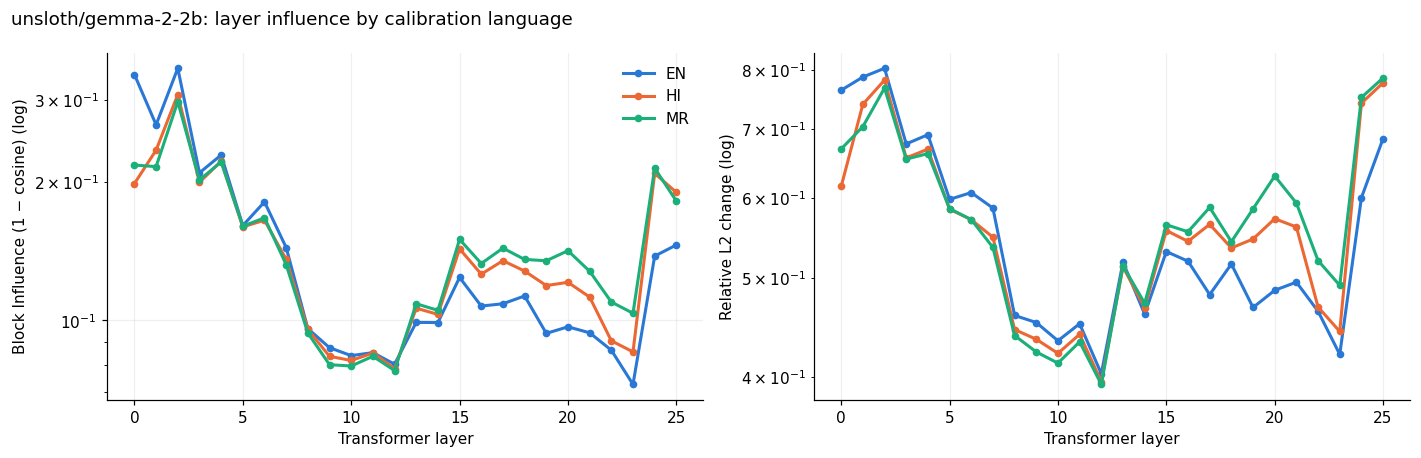

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, m, lab in zip(axes, ["bi", "rl2"], ["Block Influence (1 − cosine)", "Relative L2 change"]):
    for c in LANGS:
        ax.plot(influence[m].index, influence[m][c], marker="o", ms=4, color=COLORS[c], label=c.upper())
    ax.set_yscale("log"); ax.set_xlabel("Transformer layer"); ax.set_ylabel(lab + " (log)")
axes[0].legend(frameon=False)
fig.suptitle(f"{MODELS[MODEL_KEY]}: layer influence by calibration language", x=0.01, ha="left")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig1_layer_influence.png"); plt.show()

## 5. RQ1 — do rankings differ across languages?

Spearman/Kendall over all layers are dominated by the depth trend (first/last layers always high), so we also
report the **Jaccard overlap of the actual pruning sets** (the k lowest layers), which is what matters for pruning.

,metric,pair,spearman_rho,spearman_p,kendall_tau,kendall_p,jaccard_k2,jaccard_k4,jaccard_k6
0,bi,en-hi,0.9508,0.0,0.8277,0.0,0.3333,0.6,1.0000
1,bi,en-mr,0.9104,0.0,0.7662,0.0,0.3333,0.6,0.7143
2,bi,en-mixed,0.9610,0.0,0.8523,0.0,0.3333,0.6,0.7143
3,bi,hi-mr,0.9754,0.0,0.9015,0.0,1.0000,1.0,0.7143
4,bi,hi-mixed,0.9918,0.0,0.9631,0.0,1.0000,1.0,0.7143
5,bi,mr-mixed,0.9809,0.0,0.9138,0.0,1.0000,1.0,1.0000
6,rl2,en-hi,0.9138,0.0,0.7662,0.0,0.3333,0.6,1.0000
7,rl2,en-mr,0.8564,0.0,0.6985,0.0,0.3333,0.6,0.7143
8,rl2,en-mixed,0.9453,0.0,0.8277,0.0,0.3333,0.6,1.0000
9,rl2,hi-mr,0.9774,0.0,0.8954,0.0,1.0000,1.0,0.7143


BI pruning sets: {"en": {"2": [12, 23], "4": [10, 11, 12, 23], "6": [9, 10, 11, 12, 22, 23]}, "hi": {"2": [10, 12], "4": [9, 10, 11, 12], "6": [9, 10, 11, 12, 22, 23]}, "mr": {"2": [10, 12], "4": [9, 10, 11, 12], "6": [8, 9, 10, 11, 12, 23]}, "mixed": {"2": [10, 12], "4": [9, 10, 11, 12], "6": [8, 9, 10, 11, 12, 23]}}
RL2 pruning sets: {"en": {"2": [12, 23], "4": [10, 11, 12, 23], "6": [8, 9, 10, 11, 12, 23]}, "hi": {"2": [10, 12], "4": [9, 10, 11, 12], "6": [8, 9, 10, 11, 12, 23]}, "mr": {"2": [10, 12], "4": [9, 10, 11, 12], "6": [8, 9, 10, 11, 12, 14]}, "mixed": {"2": [10, 12], "4": [9, 10, 11, 12], "6": [8, 9, 10, 11, 12, 23]}}


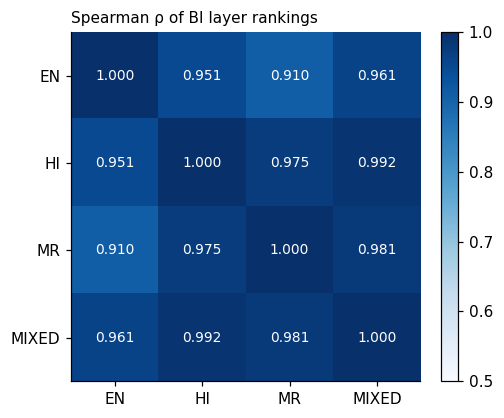

In [8]:
def lowest(vals, k):
    return sorted(int(i) for i in np.argsort(vals, kind="stable")[:k])

rank_rows = []
for m in ["bi", "rl2"]:
    df = influence[m]
    for a, b in itertools.combinations(CONDITIONS, 2):
        rho, rp = spearmanr(df[a], df[b]); tau, tp = kendalltau(df[a], df[b])
        row = {"metric": m, "pair": f"{a}-{b}", "spearman_rho": rho, "spearman_p": rp,
               "kendall_tau": tau, "kendall_p": tp}
        for k in PRUNE_LEVELS:
            A, B = set(lowest(df[a].values, k)), set(lowest(df[b].values, k))
            row[f"jaccard_k{k}"] = len(A & B) / len(A | B)
        rank_rows.append(row)
rank_df = pd.DataFrame(rank_rows)
rank_df.to_csv(OUTPUT_DIR / "rank_agreement.csv", index=False)
display(rank_df.round(4))

pruning_sets = {m: {c: {k: lowest(influence[m][c].values, k) for k in PRUNE_LEVELS} for c in CONDITIONS}
                for m in ["bi", "rl2"]}
print("BI pruning sets:", json.dumps(pruning_sets["bi"]))
print("RL2 pruning sets:", json.dumps(pruning_sets["rl2"]))
json.dump(pruning_sets, open(OUTPUT_DIR / "pruning_sets.json", "w"), indent=1)

ranks = influence["bi"].rank()
corr = ranks.corr(method="spearman")
fig, ax = plt.subplots(figsize=(4.6, 3.9))
im = ax.imshow(corr.values, cmap="Blues", vmin=min(0.5, corr.values.min()), vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels([c.upper() for c in CONDITIONS]); ax.set_yticklabels([c.upper() for c in CONDITIONS])
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{corr.values[i, j]:.3f}", ha="center", va="center",
                color="white" if corr.values[i, j] > 0.9 else "#0b0b0b", fontsize=9)
ax.grid(False); ax.set_title("Spearman ρ of BI layer rankings", loc="left", fontsize=10)
fig.colorbar(im, fraction=0.046); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig2_rank_correlation.png"); plt.show()

## 6. Pruning engine with per-chunk NLL cache

Pruning swaps the block list for a subset and restores it afterwards. Weights are never modified, so this is
equivalent to reloading a fresh model for every configuration (verified by re-computing the baseline at the end).
Results are cached per removed-layer set, so repeated sets are evaluated once.

In [9]:
@contextmanager
def pruned(remove):
    remove = set(remove)
    set_transformer_blocks(model, [b for i, b in enumerate(ORIGINAL_BLOCKS) if i not in remove], BLOCK_PATH)
    try:
        yield model
    finally:
        set_transformer_blocks(model, ORIGINAL_BLOCKS, BLOCK_PATH)

@torch.no_grad()
def chunk_nll(chunks):
    # Returns mean token NLL per chunk (SEQ_LEN-1 predicted tokens each).
    out = []
    for s in range(0, len(chunks), EVAL_BATCH):
        ids = chunks[s:s + EVAL_BATCH].to(DEVICE)
        logits = model(input_ids=ids, use_cache=False).logits
        for r in range(ids.shape[0]):
            out.append(F.cross_entropy(logits[r, :-1].float(), ids[r, 1:]).item())
        del logits
    return np.array(out)

NLL_CACHE = {}
def evaluate_set(remove):
    key = tuple(sorted(int(x) for x in remove))
    if key not in NLL_CACHE:
        with pruned(key):
            NLL_CACHE[key] = {l: chunk_nll(eval_chunks[l]) for l in LANGS}
    return NLL_CACHE[key]

ppl = lambda nll: float(np.exp(nll.mean()))

t0 = time.time()
base_nll = evaluate_set(())
baseline_ppl = {l: ppl(base_nll[l]) for l in LANGS}
print("Baseline PPL:", {l: round(v, 3) for l, v in baseline_ppl.items()}, "(%.0fs)" % (time.time() - t0))

# Bits per character: PPL is not comparable across languages with different tokenisation, BPC is.
def pred_chars(chunks):
    return np.array([len(tokenizer.decode(c[1:].tolist(), skip_special_tokens=True)) for c in chunks])
EVAL_CHARS = {l: pred_chars(eval_chunks[l]) for l in LANGS}
def bpc(nll, l):
    return float((nll * (SEQ_LEN - 1)).sum() / math.log(2) / EVAL_CHARS[l].sum())
baseline_bpc = {l: bpc(base_nll[l], l) for l in LANGS}
pd.DataFrame([{"language": l, "baseline_ppl": baseline_ppl[l], "baseline_bpc": baseline_bpc[l],
               "eval_chars": int(EVAL_CHARS[l].sum())} for l in LANGS]).to_csv(
    OUTPUT_DIR / "baseline_metrics.csv", index=False)
print("Baseline bits/char:", {l: round(v, 4) for l, v in baseline_bpc.items()})
assert all(np.isfinite(base_nll[l]).all() for l in LANGS), "non-finite NLL: numerical problem"

Baseline PPL: {'en': 9.779, 'hi': 8.208, 'mr': 9.758} (21s)
Baseline bits/char: {'en': 0.7867, 'hi': 1.2504, 'mr': 1.5934}


## 7. RQ2 — main pruning sweep (reference rankings from the full calibration pool)

In [10]:
def result_rows(remove, **meta):
    nll = evaluate_set(remove)
    rows = []
    for l in LANGS:
        p = ppl(nll[l])
        rows.append({**meta, "removed_layer_ids": str(sorted(remove)), "evaluation_language": l,
                     "baseline_ppl": baseline_ppl[l], "pruned_ppl": p,
                     "relative_ppl_degradation_pct": 100 * (p - baseline_ppl[l]) / baseline_ppl[l]})
    return rows

t0 = time.time()
main_rows = []
for m in ["bi", "rl2"]:
    for c in CONDITIONS:
        for k in PRUNE_LEVELS:
            main_rows += result_rows(pruning_sets[m][c][k], model=MODEL_KEY, metric=m, calibration=c, pruned_layers=k)
for k in PRUNE_LEVELS:   # heuristic baseline: contiguous deep block just before the final layer
    main_rows += result_rows(list(range(N_LAYERS - 1 - k, N_LAYERS - 1)), model=MODEL_KEY, metric="none",
                             calibration="deep_block", pruned_layers=k)
main_df = pd.DataFrame(main_rows)
main_df.to_csv(OUTPUT_DIR / "pruning_perplexity_results.csv", index=False)
print("done in %.0fs, unique configs evaluated: %d" % (time.time() - t0, len(NLL_CACHE)))

pivot = main_df[main_df.metric.isin(["bi", "none"])].pivot_table(
    index=["calibration", "pruned_layers"], columns="evaluation_language",
    values="relative_ppl_degradation_pct")[LANGS]
display(pivot.round(2))

done in 205s, unique configs evaluated: 11


evaluation_language             en          hi          mr
calibration pruned_layers                                 
deep_block  2                74.88     1496.86     3704.09
            4               478.65    51536.44   271606.49
            6              2459.69  1654642.44  2823983.95
en          2                26.19       37.73       67.71
            4                48.18       64.99       95.93
            6               126.25      187.18      327.47
hi          2                17.01       16.77       18.64
            4                34.85       33.48       36.30
            6               126.25      187.18      327.47
mixed       2                17.01       16.77       18.64
            4                34.85       33.48       36.30
            6                85.30      106.63      158.32
mr          2                17.01       16.77       18.64
            4                34.85       33.48       36.30
            6                85.30      106.63      158.32

### Random-pruning control (10 seeds per k)

In [11]:
t0 = time.time()
rand_rows = []
for k in PRUNE_LEVELS:
    for s in range(N_RANDOM_SEEDS):
        rem = sorted(random.Random(1000 + 97 * k + s).sample(range(N_LAYERS), k))
        rand_rows += result_rows(rem, model=MODEL_KEY, metric="random", calibration="random", pruned_layers=k, seed=s)
rand_df = pd.DataFrame(rand_rows)
rand_df.to_csv(OUTPUT_DIR / "random_pruning_results.csv", index=False)
rand_summary = rand_df.groupby(["pruned_layers", "evaluation_language"]).relative_ppl_degradation_pct.agg(
    ["median", "mean", "std", "min", "max"]).round(2)
display(rand_summary)
print("%.0fs" % (time.time() - t0))

median         mean           std  \
pruned_layers evaluation_language                                         
2             en                       33.76        64.19  4.792000e+01   
              hi                       65.11       199.32  4.094700e+02   
              mr                       95.28       287.86  6.379600e+02   
4             en                      336.66       321.33  1.451400e+02   
              hi                     1719.25      2302.10  1.985860e+03   
              mr                     1608.40      4679.15  5.461170e+03   
6             en                     2342.54     14236.68  2.801414e+04   
              hi                    55086.53  28470538.06  6.589398e+07   
              mr                   100880.77  58662665.96  1.243778e+08   

                                      min           max  
pruned_layers evaluation_language                        
2             en                    29.06  1.682000e+02  
              hi                    36.31  1.361620e+03  
              mr                    44.52  2.101320e+03  
4             en                    57.62  5.244600e+02  
              hi                   155.18  5.412130e+03  
              mr                   184.46  1.563133e+04  
6             en                   153.21  8.846568e+04  
              hi                   185.57  2.045898e+08  
              mr                   238.48  3.464645e+08

599s


### Paired bootstrap: is English-calibrated pruning worse on Indic text than language-matched pruning?

For eval language L, $\Delta = \log PPL(\text{EN-calibrated}) - \log PPL(\text{L-calibrated})$ on the *same*
evaluation chunks; positive Δ means English calibration transfers worse. 95% CI from 2000 resamples of chunks.

In [12]:
rng = np.random.default_rng(SEED)
def boot_delta(nll_a, nll_b):
    d = nll_a - nll_b
    idx = rng.integers(0, len(d), size=(N_BOOT, len(d)))
    bs = d[idx].mean(1)
    return d.mean(), np.percentile(bs, 2.5), np.percentile(bs, 97.5)

contrast_rows = []
for m in ["bi", "rl2"]:
    for k in PRUNE_LEVELS:
        for L in LANGS:
            for a, b in [("en", L), ("mixed", L), ("en", "mixed")]:
                if a == b:
                    continue
                na = evaluate_set(pruning_sets[m][a][k])[L]; nb = evaluate_set(pruning_sets[m][b][k])[L]
                mean, lo, hi = boot_delta(na, nb)
                contrast_rows.append({"metric": m, "k": k, "eval_language": L, "contrast": f"{a} vs {b}",
                                      "same_layer_set": pruning_sets[m][a][k] == pruning_sets[m][b][k],
                                      "delta_logppl": mean, "ci_low": lo, "ci_high": hi,
                                      "ppl_ratio": math.exp(mean),
                                      "significant": (lo > 0) or (hi < 0)})
contrast_df = pd.DataFrame(contrast_rows)
contrast_df.to_csv(OUTPUT_DIR / "bootstrap_contrasts.csv", index=False)
display(contrast_df[contrast_df.metric == "bi"].round(4))

,metric,k,eval_language,contrast,same_layer_set,delta_logppl,ci_low,ci_high,ppl_ratio,significant
0,bi,2,en,mixed vs en,False,-0.0755,-0.0878,-0.0618,0.9273,True
1,bi,2,en,en vs mixed,False,0.0755,0.0628,0.0884,1.0784,True
2,bi,2,hi,en vs hi,False,0.1651,0.1518,0.1782,1.1795,True
3,bi,2,hi,mixed vs hi,True,0.0000,0.0000,0.0000,1.0000,False
4,bi,2,hi,en vs mixed,False,0.1651,0.1516,0.1778,1.1795,True
5,bi,2,mr,en vs mr,False,0.3461,0.3284,0.3649,1.4136,True
6,bi,2,mr,mixed vs mr,True,0.0000,0.0000,0.0000,1.0000,False
7,bi,2,mr,en vs mixed,False,0.3461,0.3282,0.3645,1.4136,True
8,bi,4,en,mixed vs en,False,-0.0942,-0.1076,-0.0814,0.9101,True
9,bi,4,en,en vs mixed,False,0.0942,0.0807,0.1078,1.0988,True


## 8. Calibration seeds: ranking stability (Jaccard) and seeded pruning (mean ± std)

In [13]:
def draw_subset(cond, budget, seed):
    r = np.random.default_rng(seed)
    if cond == "mixed":
        per = max(1, budget // 3)
        return {l: r.choice(CALIB_POOL_CHUNKS, per, replace=False) for l in LANGS}
    return {cond: r.choice(CALIB_POOL_CHUNKS, budget, replace=False)}

t0 = time.time()
stab_rows, seeded_rows = [], []
for c in CONDITIONS:
    sets_by_seed = []
    for s in range(N_SEEDS):
        inf = subset_influence(c, "bi", draw_subset(c, SEEDED_BUDGET, 10_000 + s))
        sets_by_seed.append({k: lowest(inf, k) for k in PRUNE_LEVELS})
        for k in PRUNE_LEVELS:
            seeded_rows += result_rows(sets_by_seed[-1][k], model=MODEL_KEY, metric="bi", calibration=c,
                                       pruned_layers=k, seed=s, budget=SEEDED_BUDGET)
    for k in PRUNE_LEVELS:
        js = [len(set(a[k]) & set(b[k])) / len(set(a[k]) | set(b[k]))
              for a, b in itertools.combinations(sets_by_seed, 2)]
        ref = set(pruning_sets["bi"][c][k])
        jr = [len(set(a[k]) & ref) / len(set(a[k]) | ref) for a in sets_by_seed]
        stab_rows.append({"calibration": c, "k": k, "budget_chunks": SEEDED_BUDGET,
                          "pairwise_jaccard_mean": np.mean(js), "pairwise_jaccard_std": np.std(js),
                          "jaccard_vs_full_pool_mean": np.mean(jr), "n_seeds": N_SEEDS})
stability_df = pd.DataFrame(stab_rows)
stability_df.to_csv(OUTPUT_DIR / "ranking_stability.csv", index=False)
seeded_df = pd.DataFrame(seeded_rows)
seeded_df.to_csv(OUTPUT_DIR / "seeded_pruning_results.csv", index=False)
display(stability_df.round(3))
seeded_summary = seeded_df.groupby(["calibration", "pruned_layers", "evaluation_language"]
    ).relative_ppl_degradation_pct.agg(["mean", "std"]).unstack("evaluation_language").round(2)
display(seeded_summary)
print("%.0fs, cache size %d" % (time.time() - t0, len(NLL_CACHE)))

,calibration,k,budget_chunks,pairwise_jaccard_mean,pairwise_jaccard_std,jaccard_vs_full_pool_mean,n_seeds
0,en,2,60,1.000,0.000,1.000,5
1,en,4,60,0.840,0.196,0.920,5
2,en,6,60,1.000,0.000,1.000,5
3,hi,2,60,1.000,0.000,1.000,5
4,hi,4,60,1.000,0.000,1.000,5
5,hi,6,60,1.000,0.000,1.000,5
6,mr,2,60,0.733,0.327,0.867,5
7,mr,4,60,1.000,0.000,1.000,5
8,mr,6,60,1.000,0.000,1.000,5
9,mixed,2,60,1.000,0.000,1.000,5


mean                    std              
evaluation_language            en      hi      mr     en     hi     mr
calibration pruned_layers                                             
en          2               26.19   37.73   67.71   0.00   0.00   0.00
            4               57.33   81.00  131.75  20.46  35.80  80.09
            6              126.25  187.18  327.47   0.00   0.00   0.00
hi          2               17.01   16.77   18.64   0.00   0.00   0.00
            4               34.85   33.48   36.30   0.00   0.00   0.00
            6              126.25  187.18  327.47   0.00   0.00   0.00
mixed       2               17.01   16.77   18.64   0.00   0.00   0.00
            4               34.85   33.48   36.30   0.00   0.00   0.00
            6               93.49  122.74  192.15  18.31  36.02  75.65
mr          2               16.93   16.41   18.20   0.18   0.80   0.99
            4               34.85   33.48   36.30   0.00   0.00   0.00
            6               85.30  106.63  158.32   0.00   0.00   0.00

42s, cache size 42


## 9. RQ3 — calibration-budget sweep (k = 4)

In [14]:
t0 = time.time()
budget_rows = []
for B in BUDGETS:
    for c in CONDITIONS:
        for s in range(N_SEEDS):
            idx = draw_subset(c, B, 20_000 + 31 * B + s)
            rem = lowest(subset_influence(c, "bi", idx), BUDGET_K)
            ref = set(pruning_sets["bi"][c][BUDGET_K])
            j = len(set(rem) & ref) / len(set(rem) | ref)
            for row in result_rows(rem, model=MODEL_KEY, metric="bi", calibration=c, pruned_layers=BUDGET_K,
                                   seed=s, budget=B):
                row["jaccard_vs_full_pool"] = j
                budget_rows.append(row)
budget_df = pd.DataFrame(budget_rows)
budget_df.to_csv(OUTPUT_DIR / "calibration_budget_sweep.csv", index=False)
budget_summary = budget_df.groupby(["budget", "calibration", "evaluation_language"]).agg(
    deg_mean=("relative_ppl_degradation_pct", "mean"), deg_std=("relative_ppl_degradation_pct", "std"),
    jaccard_mean=("jaccard_vs_full_pool", "mean")).round(3)
display(budget_summary.unstack("evaluation_language"))
print("%.0fs, cache size %d" % (time.time() - t0, len(NLL_CACHE)))

deg_mean                  deg_std                  \
evaluation_language       en      hi       mr      en      hi      mr   
budget calibration                                                      
3      en             67.006  97.741  170.499  24.605  43.210  95.597   
       hi             43.899  53.844   77.946   8.326  18.649  38.485   
       mixed          41.234  47.542   66.019   8.736  19.256  40.694   
       mr             34.854  33.480   36.300   0.000   0.000   0.000   
6      en             48.180  64.987   95.934   0.000   0.000   0.000   
       hi             47.614  61.604   95.737   7.133  15.722  33.227   
       mixed          38.044  40.511   51.159   7.133  15.722  33.227   
       mr             34.854  33.480   36.300   0.000   0.000   0.000   
15     en             66.481  97.011  167.566  25.060  43.850  98.086   
       hi             41.234  47.542   66.019   8.736  19.256  40.694   
       mixed          34.854  33.480   36.300   0.000   0.000   0.000   
       mr             34.854  33.480   36.300   0.000   0.000   0.000   
30     en             66.481  97.011  167.566  25.060  43.850  98.086   
       hi             41.234  47.542   66.019   8.736  19.256  40.694   
       mixed          34.854  33.480   36.300   0.000   0.000   0.000   
       mr             34.854  33.480   36.300   0.000   0.000   0.000   
60     en             48.180  64.987   95.934   0.000   0.000   0.000   
       hi             38.044  40.511   51.159   7.133  15.722  33.227   
       mixed          34.854  33.480   36.300   0.000   0.000   0.000   
       mr             34.854  33.480   36.300   0.000   0.000   0.000   
150    en             48.180  64.987   95.934   0.000   0.000   0.000   
       hi             34.854  33.480   36.300   0.000   0.000   0.000   
       mixed          34.854  33.480   36.300   0.000   0.000   0.000   
       mr             34.854  33.480   36.300   0.000   0.000   0.000   

                    jaccard_mean              
evaluation_language           en    hi    mr  
budget calibration                            
3      en                   0.76  0.76  0.76  
       hi                   0.76  0.76  0.76  
       mixed                0.84  0.84  0.84  
       mr                   1.00  1.00  1.00  
6      en                   1.00  1.00  1.00  
       hi                   0.68  0.68  0.68  
       mixed                0.92  0.92  0.92  
       mr                   1.00  1.00  1.00  
15     en                   0.84  0.84  0.84  
       hi                   0.84  0.84  0.84  
       mixed                1.00  1.00  1.00  
       mr                   1.00  1.00  1.00  
30     en                   0.84  0.84  0.84  
       hi                   0.84  0.84  0.84  
       mixed                1.00  1.00  1.00  
       mr                   1.00  1.00  1.00  
60     en                   1.00  1.00  1.00  
       hi                   0.92  0.92  0.92  
       mixed                1.00  1.00  1.00  
       mr                   1.00  1.00  1.00  
150    en                   1.00  1.00  1.00  
       hi                   1.00  1.00  1.00  
       mixed                1.00  1.00  1.00  
       mr                   1.00  1.00  1.00

20s, cache size 43


## 10. Figures

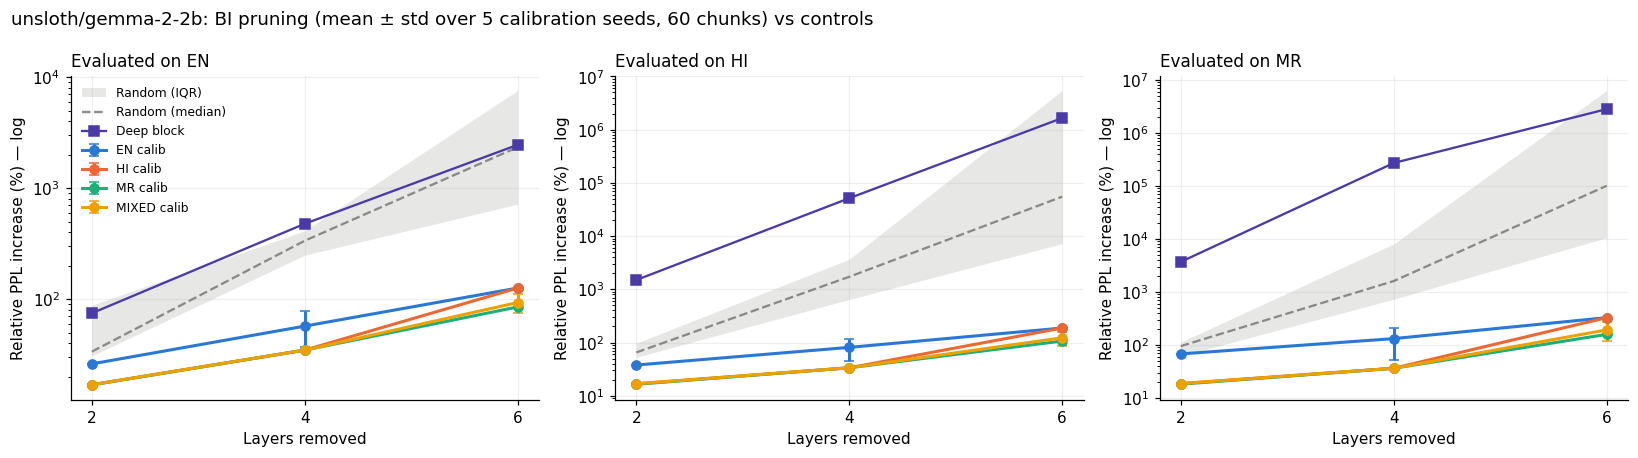

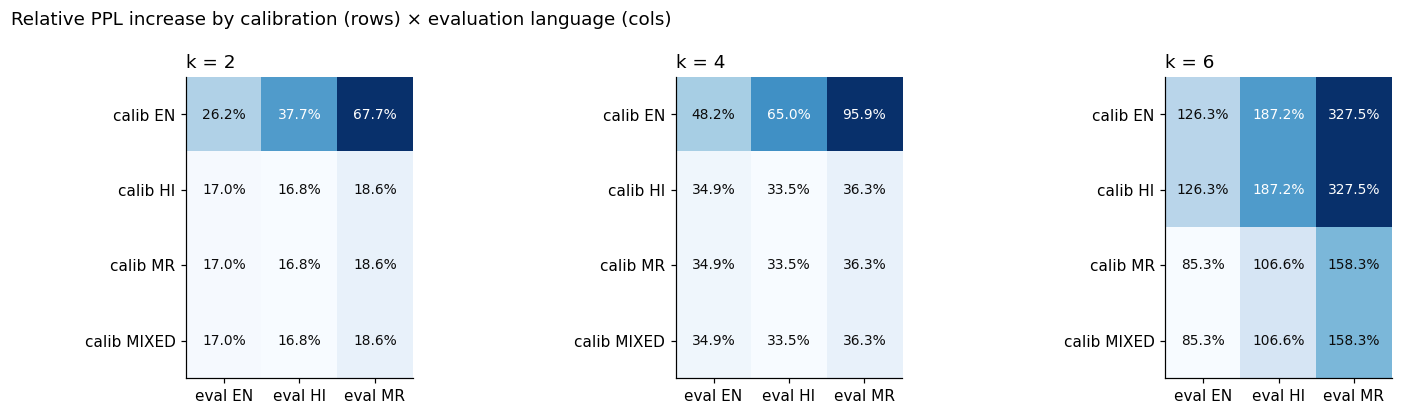

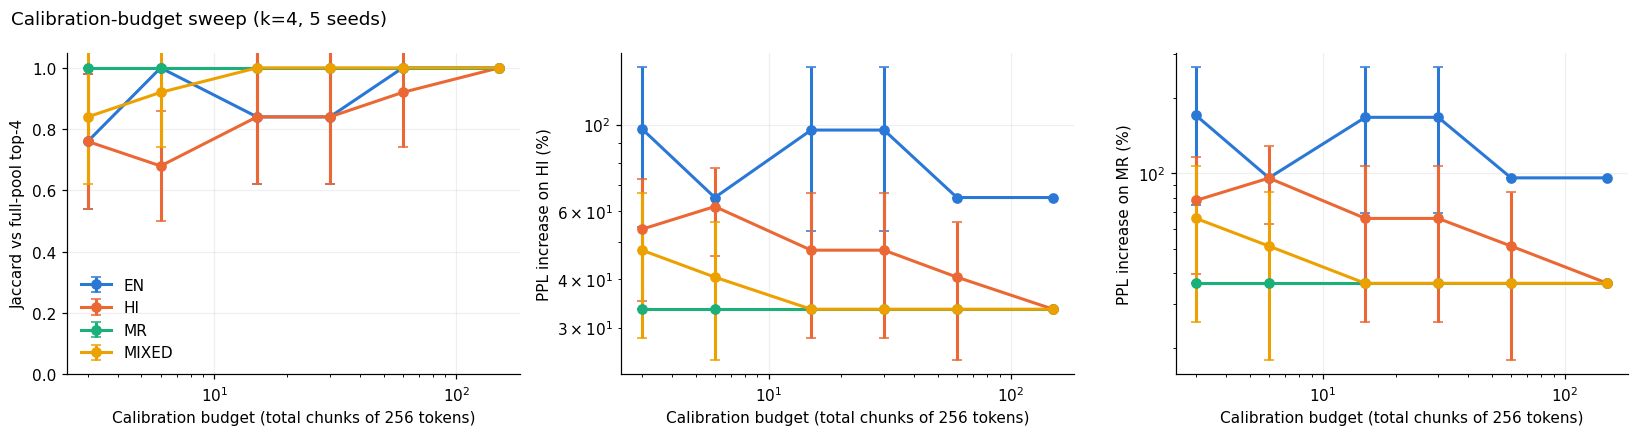

In [15]:
# Fig 3: degradation vs k per evaluation language, with random band
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=False)
bi = main_df[main_df.metric == "bi"]
for ax, L in zip(axes, LANGS):
    r = rand_df[rand_df.evaluation_language == L].groupby("pruned_layers").relative_ppl_degradation_pct
    q25, q50, q75 = r.quantile(0.25), r.median(), r.quantile(0.75)
    ax.fill_between(PRUNE_LEVELS, q25, q75, color=COLORS["random"], alpha=0.2, lw=0, label="Random (IQR)")
    ax.plot(PRUNE_LEVELS, q50, color=COLORS["random"], ls="--", lw=1.5, label="Random (median)")
    for c in CONDITIONS:
        sub = seeded_df[(seeded_df.calibration == c) & (seeded_df.evaluation_language == L)].groupby(
            "pruned_layers").relative_ppl_degradation_pct
        ax.errorbar(PRUNE_LEVELS, sub.mean(), yerr=sub.std(), marker="o", ms=6, capsize=3,
                    color=COLORS[c], label=f"{c.upper()} calib")
    d = main_df[(main_df.calibration == "deep_block") & (main_df.evaluation_language == L)]
    ax.plot(d.pruned_layers, d.relative_ppl_degradation_pct, marker="s", ms=6, color=COLORS["deep_block"],
            lw=1.5, label="Deep block")
    ax.set_yscale("log"); ax.set_xticks(PRUNE_LEVELS)
    ax.set_title(f"Evaluated on {L.upper()}", loc="left", fontsize=11)
    ax.set_xlabel("Layers removed"); ax.set_ylabel("Relative PPL increase (%) — log")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"{MODELS[MODEL_KEY]}: BI pruning (mean ± std over {N_SEEDS} calibration seeds, "
             f"{SEEDED_BUDGET} chunks) vs controls", x=0.01, ha="left")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig3_ppl_degradation_vs_k.png"); plt.show()

# Fig 4: calibration x evaluation matrix (full-pool rankings), one panel per k
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, k in zip(axes, PRUNE_LEVELS):
    mat = bi[bi.pruned_layers == k].pivot(index="calibration", columns="evaluation_language",
                                          values="relative_ppl_degradation_pct").loc[CONDITIONS, LANGS]
    lv = np.log10(mat.values.clip(0.01)); lo, hi_ = lv.min(), max(lv.max(), lv.min() + 1e-9)
    im = ax.imshow(lv, cmap="Blues", vmin=lo, vmax=hi_)
    ax.set_xticks(range(3)); ax.set_xticklabels([f"eval {l.upper()}" for l in LANGS])
    ax.set_yticks(range(4)); ax.set_yticklabels([f"calib {c.upper()}" for c in CONDITIONS])
    for i in range(4):
        for j in range(3):
            v = mat.values[i, j]
            ax.text(j, i, f"{v:.1f}%", ha="center", va="center", fontsize=9,
                    color="white" if (lv[i, j] - lo) / (hi_ - lo) > 0.55 else "#0b0b0b")
    ax.grid(False); ax.set_title(f"k = {k}", loc="left")
fig.suptitle("Relative PPL increase by calibration (rows) × evaluation language (cols)", x=0.01, ha="left")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig4_calibration_x_evaluation.png"); plt.show()

# Fig 5: calibration budget sweep — stability and Indic degradation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bs = budget_df.groupby(["budget", "calibration", "seed"]).jaccard_vs_full_pool.first().reset_index()
for c in CONDITIONS:
    g = bs[bs.calibration == c].groupby("budget").jaccard_vs_full_pool
    axes[0].errorbar(g.mean().index, g.mean(), yerr=g.std(), marker="o", capsize=3, color=COLORS[c], label=c.upper())
    for ax, L in zip(axes[1:], ["hi", "mr"]):
        g2 = budget_df[(budget_df.calibration == c) & (budget_df.evaluation_language == L)].groupby(
            "budget").relative_ppl_degradation_pct
        ax.errorbar(g2.mean().index, g2.mean(), yerr=g2.std(), marker="o", capsize=3, color=COLORS[c], label=c.upper())
axes[0].set_ylabel(f"Jaccard vs full-pool top-{BUDGET_K}"); axes[0].set_ylim(0, 1.05)
for ax, L in zip(axes[1:], ["hi", "mr"]):
    ax.set_ylabel(f"PPL increase on {L.upper()} (%)"); ax.set_yscale("log")
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("Calibration budget (total chunks of 256 tokens)")
axes[0].legend(frameon=False)
fig.suptitle(f"Calibration-budget sweep (k={BUDGET_K}, {N_SEEDS} seeds)", x=0.01, ha="left")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig5_budget_sweep.png"); plt.show()

## 11. Downstream task — Belebele reading comprehension (EN / HI / MR)

Belebele is fully parallel: the **same** 300 questions are asked in all three languages, so differences are
paired. Zero-shot, 4-way multiple choice, scored by the next-token probability of the letters A–D (chance = 25%).
Evaluated for the baseline, every full-pool BI pruning set, and random-pruning controls.

Belebele questions per language: 300 | mean prompt tokens: {'en': 153, 'hi': 264, 'mr': 316}


baseline done 138s


Belebele done in 1583s, unique configs: 13


evaluation_language           en     hi     mr
calibration pruned_layers                     
baseline    0              0.473  0.287  0.280
en          2              0.317  0.263  0.273
            4              0.217  0.223  0.230
            6              0.220  0.233  0.233
hi          2              0.307  0.280  0.233
            4              0.243  0.230  0.230
            6              0.220  0.233  0.233
mixed       2              0.307  0.280  0.233
            4              0.243  0.230  0.230
            6              0.227  0.223  0.230
mr          2              0.307  0.280  0.233
            4              0.243  0.230  0.230
            6              0.227  0.223  0.230

,k,eval_language,contrast,same_layer_set,acc_diff,ci_low,ci_high,significant
0,2,hi,en vs hi,False,-0.0167,-0.0700,0.0400,False
1,2,hi,en vs mixed,False,-0.0167,-0.0767,0.0400,False
2,2,mr,en vs mr,False,0.0400,-0.0100,0.0900,False
3,2,mr,en vs mixed,False,0.0400,-0.0067,0.0867,False
4,4,hi,en vs hi,False,-0.0067,-0.0167,0.0000,False
5,4,hi,en vs mixed,False,-0.0067,-0.0167,0.0000,False
6,4,mr,en vs mr,False,0.0000,0.0000,0.0000,False
7,4,mr,en vs mixed,False,0.0000,0.0000,0.0000,False
8,6,hi,en vs hi,True,0.0000,0.0000,0.0000,False
9,6,hi,en vs mixed,False,0.0100,0.0000,0.0233,False


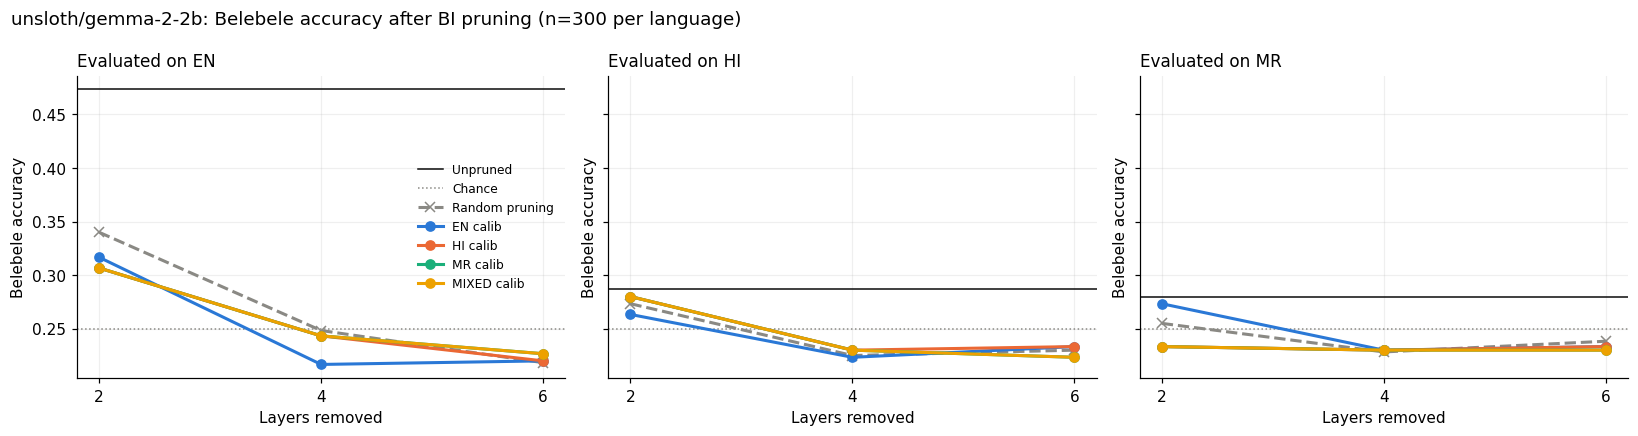

In [16]:
if RUN_BELEBELE:
    def load_belebele(lang):
        cache = DATA_CACHE / f"belebele_{lang}.json"
        if cache.exists():
            return json.loads(cache.read_text(encoding="utf-8"))
        ds = load_dataset("facebook/belebele", BELEBELE_CODES[lang], split="test")
        rows = [{k: r[k] for k in ["link", "question_number", "flores_passage", "question", "mc_answer1",
                                   "mc_answer2", "mc_answer3", "mc_answer4", "correct_answer_num"]} for r in ds]
        cache.write_text(json.dumps(rows, ensure_ascii=False), encoding="utf-8")
        return rows

    bele_raw = {l: {(r["link"], r["question_number"]): r for r in load_belebele(l)} for l in LANGS}
    common = sorted(set.intersection(*[set(v) for v in bele_raw.values()]))
    qkeys = [common[i] for i in np.random.default_rng(SEED).permutation(len(common))[:N_BELEBELE]]

    def bele_prompt(r):
        return (f"P: {r['flores_passage']}\nQ: {r['question']}\nA: {r['mc_answer1']}\nB: {r['mc_answer2']}\n"
                f"C: {r['mc_answer3']}\nD: {r['mc_answer4']}\nAnswer:")

    LETTER_IDS = [tokenizer.encode(" " + L, add_special_tokens=False)[-1] for L in "ABCD"]
    assert len(set(LETTER_IDS)) == 4, LETTER_IDS
    bele_ids = {l: [torch.tensor(tokenizer(bele_prompt(bele_raw[l][q]))["input_ids"]) for q in qkeys] for l in LANGS}
    bele_gold = {l: np.array([int(bele_raw[l][q]["correct_answer_num"]) - 1 for q in qkeys]) for l in LANGS}
    print("Belebele questions per language:", len(qkeys),
          "| mean prompt tokens:", {l: int(np.mean([len(x) for x in bele_ids[l]])) for l in LANGS})

    @torch.no_grad()
    def bele_correct(lang):
        preds = []
        for ids in bele_ids[lang]:
            out = model(input_ids=ids[None].to(DEVICE), use_cache=False, logits_to_keep=1)
            preds.append(int(out.logits[0, -1, LETTER_IDS].argmax()))
        return np.array(preds) == bele_gold[lang]

    BELE_CACHE = {}
    def bele_set(remove):
        key = tuple(sorted(int(x) for x in remove))
        if key not in BELE_CACHE:
            with pruned(key):
                BELE_CACHE[key] = {l: bele_correct(l) for l in LANGS}
        return BELE_CACHE[key]

    t0 = time.time()
    bele_rows = []
    def add_bele(remove, **meta):
        res = bele_set(remove)
        for l in LANGS:
            bele_rows.append({**meta, "removed_layer_ids": str(sorted(remove)), "evaluation_language": l,
                              "accuracy": res[l].mean(), "n_questions": len(res[l])})
    add_bele((), model=MODEL_KEY, calibration="baseline", pruned_layers=0)
    print("baseline done %.0fs" % (time.time() - t0))
    for c in CONDITIONS:
        for k in PRUNE_LEVELS:
            add_bele(pruning_sets["bi"][c][k], model=MODEL_KEY, calibration=c, pruned_layers=k)
    for k in PRUNE_LEVELS:
        for s in range(BELEBELE_RANDOM_SEEDS):
            rem = sorted(random.Random(1000 + 97 * k + s).sample(range(N_LAYERS), k))   # same sets as PPL control
            add_bele(rem, model=MODEL_KEY, calibration="random", pruned_layers=k, seed=s)
    bele_df = pd.DataFrame(bele_rows)
    bele_df.to_csv(OUTPUT_DIR / "belebele_results.csv", index=False)
    print("Belebele done in %.0fs, unique configs: %d" % (time.time() - t0, len(BELE_CACHE)))
    display(bele_df[bele_df.calibration != "random"].pivot_table(
        index=["calibration", "pruned_layers"], columns="evaluation_language", values="accuracy")[LANGS].round(3))

    # Paired bootstrap on accuracy: EN-calibrated vs language-matched pruning, same questions
    brows = []
    for k in PRUNE_LEVELS:
        for L in ["hi", "mr"]:
            for a, b in [("en", L), ("en", "mixed")]:
                ca = bele_set(pruning_sets["bi"][a][k])[L].astype(float)
                cb = bele_set(pruning_sets["bi"][b][k])[L].astype(float)
                d = ca - cb
                bs = d[rng.integers(0, len(d), size=(N_BOOT, len(d)))].mean(1)
                brows.append({"k": k, "eval_language": L, "contrast": f"{a} vs {b}",
                              "same_layer_set": pruning_sets["bi"][a][k] == pruning_sets["bi"][b][k],
                              "acc_diff": d.mean(), "ci_low": np.percentile(bs, 2.5),
                              "ci_high": np.percentile(bs, 97.5)})
    bele_contrast_df = pd.DataFrame(brows)
    bele_contrast_df["significant"] = (bele_contrast_df.ci_low > 0) | (bele_contrast_df.ci_high < 0)
    bele_contrast_df.to_csv(OUTPUT_DIR / "belebele_bootstrap_contrasts.csv", index=False)
    display(bele_contrast_df.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, L in zip(axes, LANGS):
        base_acc = bele_df[(bele_df.calibration == "baseline") & (bele_df.evaluation_language == L)].accuracy.iloc[0]
        ax.axhline(base_acc, color="#0b0b0b", lw=1, label="Unpruned")
        ax.axhline(0.25, color=COLORS["random"], lw=1, ls=":", label="Chance")
        r = bele_df[(bele_df.calibration == "random") & (bele_df.evaluation_language == L)].groupby("pruned_layers").accuracy
        ax.plot(PRUNE_LEVELS, r.mean(), color=COLORS["random"], ls="--", marker="x", label="Random pruning")
        for c in CONDITIONS:
            sub = bele_df[(bele_df.calibration == c) & (bele_df.evaluation_language == L)].sort_values("pruned_layers")
            ax.plot(sub.pruned_layers, sub.accuracy, marker="o", color=COLORS[c], label=f"{c.upper()} calib")
        ax.set_xticks(PRUNE_LEVELS); ax.set_xlabel("Layers removed"); ax.set_ylabel("Belebele accuracy")
        ax.set_title(f"Evaluated on {L.upper()}", loc="left", fontsize=11)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"{MODELS[MODEL_KEY]}: Belebele accuracy after BI pruning (n={len(qkeys)} per language)",
                 x=0.01, ha="left")
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig6_belebele.png"); plt.show()
else:
    print("Belebele skipped (RUN_BELEBELE=0)")

## 12. Sanity check and experiment summary

In [17]:
recheck = {l: ppl(chunk_nll(eval_chunks[l])) for l in LANGS}
assert all(abs(recheck[l] - baseline_ppl[l]) / baseline_ppl[l] < 1e-3 for l in LANGS), (recheck, baseline_ppl)
print("Model restored correctly after all pruning runs:", {l: round(v, 3) for l, v in recheck.items()})

summary = {**model_info, "transformers": transformers.__version__, "torch": torch.__version__,
           "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu", "dtype": str(DTYPE),
           "seq_len": SEQ_LEN, "calib_pool_chunks": CALIB_POOL_CHUNKS, "eval_chunks": EVAL_CHUNKS,
           "n_seeds": N_SEEDS, "seeded_budget": SEEDED_BUDGET, "budgets": BUDGETS,
           "n_random_seeds": N_RANDOM_SEEDS, "seed": SEED, "baseline_ppl": baseline_ppl,
           "baseline_bpc": baseline_bpc, "unique_configs_evaluated": len(NLL_CACHE),
           "belebele": RUN_BELEBELE, "n_belebele": N_BELEBELE if RUN_BELEBELE else 0}
np.savez_compressed(OUTPUT_DIR / "per_chunk_nll.npz",
                    **{("-".join(map(str, k)) or "none") + "__" + l: v[l] for k, v in NLL_CACHE.items() for l in LANGS})
json.dump(summary, open(OUTPUT_DIR / "experiment_config.json", "w"), indent=2)
print("Saved to", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)

Model restored correctly after all pruning runs: {'en': 9.779, 'hi': 8.208, 'mr': 9.758}
Saved to results\gemma
 - baseline_metrics.csv
 - belebele_bootstrap_contrasts.csv
 - belebele_results.csv
 - block_influence_bi_by_language.csv
 - block_influence_by_language.csv
 - block_influence_rl2_by_language.csv
 - bootstrap_contrasts.csv
 - calibration_budget_sweep.csv
 - data_split.csv
 - diagnostic_v1_last_layer.csv
 - experiment_config.json
 - fig1_layer_influence.png
 - fig2_rank_correlation.png
 - fig3_ppl_degradation_vs_k.png
 - fig4_calibration_x_evaluation.png
 - fig5_budget_sweep.png
 - fig6_belebele.png
 - per_chunk_nll.npz
 - pruning_perplexity_results.csv
 - pruning_sets.json
 - random_pruning_results.csv
 - rank_agreement.csv
 - ranking_stability.csv
 - seeded_pruning_results.csv
 - tokenizer_tokens_per_word.csv
